<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

СӨЖ №17
Transformer архитектурасындағы Self-Attention және Multi-Head Attention механизмдерін Python тілінде іске асыру
Мақсаты

Transformer архитектурасының негізгі компоненттерінің жұмыс принципін меңгеру және оларды бағдарламалық түрде жүзеге асыру.

1. Қажетті кітапханаларды қосу

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)

2. Мәтінді дайындау

Кемінде 10 сөзден тұратын сөйлем:

In [3]:
sentence = "transformer models use attention mechanisms to process natural language efficiently"

tokens = sentence.split()

vocab = {word: idx for idx, word in enumerate(set(tokens))}
vocab_size = len(vocab)

token_ids = torch.tensor([vocab[word] for word in tokens])

print(tokens)
print(token_ids)

['transformer', 'models', 'use', 'attention', 'mechanisms', 'to', 'process', 'natural', 'language', 'efficiently']
tensor([9, 6, 7, 4, 5, 2, 0, 8, 3, 1])


3. Embedding қабаты

In [4]:
d_model = 32

embedding = nn.Embedding(vocab_size, d_model)

X = embedding(token_ids)

print(X.shape)

torch.Size([10, 32])


In [5]:
torch.Size([10, 32])

torch.Size([10, 32])

4. Self-Attention механизмін нөлден жүзеге асыру
Query, Key, Value матрицаларын есептеу

In [6]:
class SelfAttention(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

    def forward(self, x):

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / np.sqrt(d_model)

        weights = F.softmax(scores, dim=-1)

        output = torch.matmul(weights, V)

        return output, scores, weights

5. Self-Attention іске қосу

In [7]:
self_attention = SelfAttention(d_model)

attention_output, scores, weights = self_attention(X)

print("Attention Output Shape:", attention_output.shape)
print("Scores Shape:", scores.shape)
print("Weights Shape:", weights.shape)

Attention Output Shape: torch.Size([10, 32])
Scores Shape: torch.Size([10, 10])
Weights Shape: torch.Size([10, 10])


6. Attention Scores визуализациясы

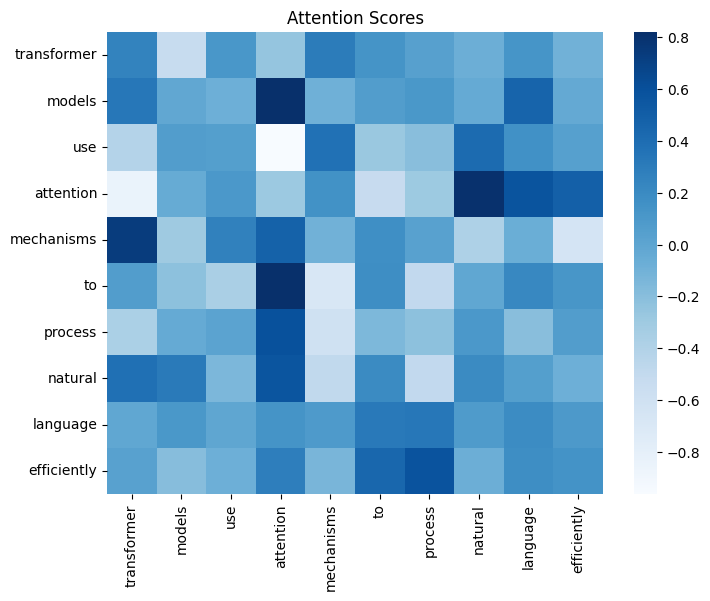

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    scores.detach().numpy(),
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="Blues"
)

plt.title("Attention Scores")
plt.show()

7. Attention Weights визуализациясы

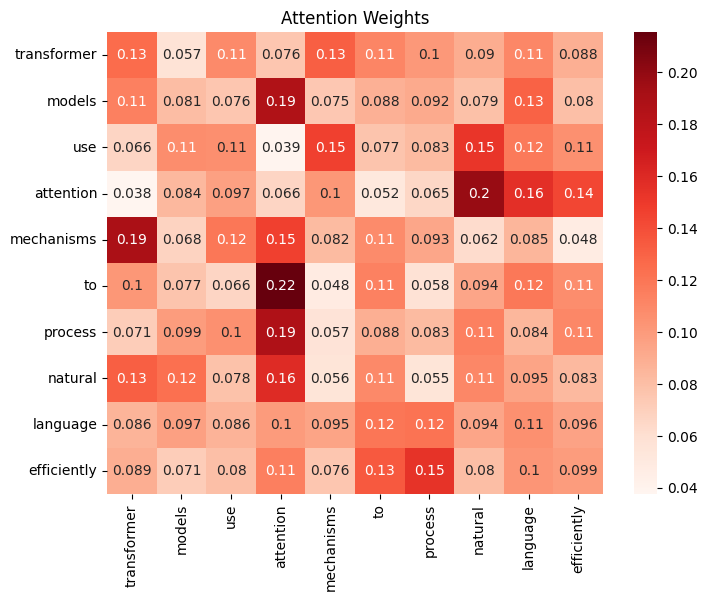

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    weights.detach().numpy(),
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="Reds",
    annot=True
)

plt.title("Attention Weights")
plt.show()

8. Multi-Head Attention модулі

Кемінде 4 head қолданамыз.

In [10]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):

        batch_size = 1
        seq_len = x.shape[0]

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(seq_len, self.num_heads, self.head_dim)
        K = K.view(seq_len, self.num_heads, self.head_dim)
        V = V.view(seq_len, self.num_heads, self.head_dim)

        Q = Q.transpose(0,1)
        K = K.transpose(0,1)
        V = V.transpose(0,1)

        scores = torch.matmul(Q, K.transpose(-2,-1))
        scores = scores / np.sqrt(self.head_dim)

        weights = F.softmax(scores, dim=-1)

        attention = torch.matmul(weights, V)

        attention = attention.transpose(0,1)
        attention = attention.contiguous().view(seq_len, d_model)

        output = self.fc(attention)

        return output, weights

9. Multi-Head Attention тесті

In [11]:
mha = MultiHeadAttention(
    d_model=32,
    num_heads=4
)

mha_output, mha_weights = mha(X)

print(mha_output.shape)

torch.Size([10, 32])


10. Әр head үшін attention карталары

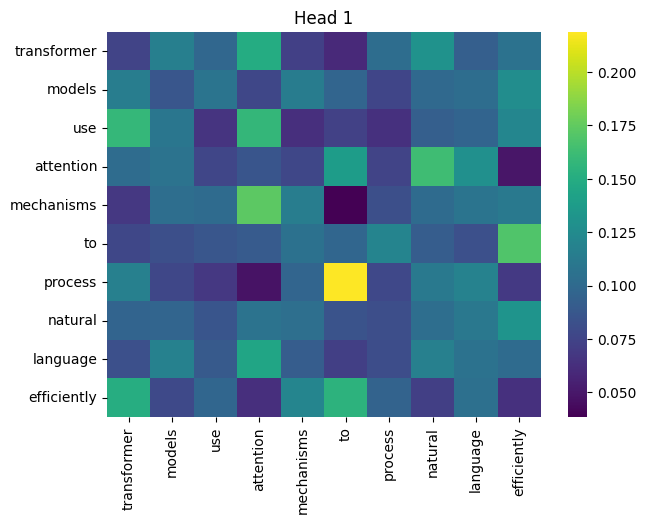

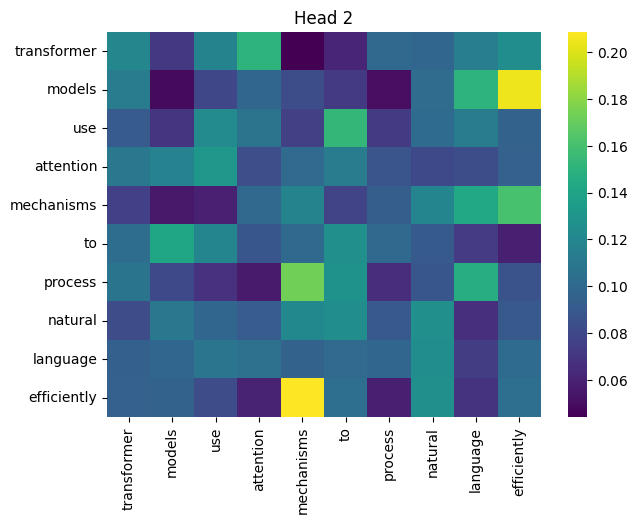

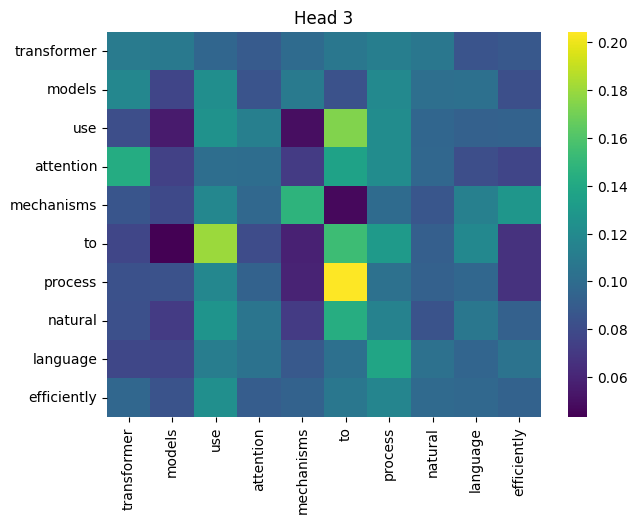

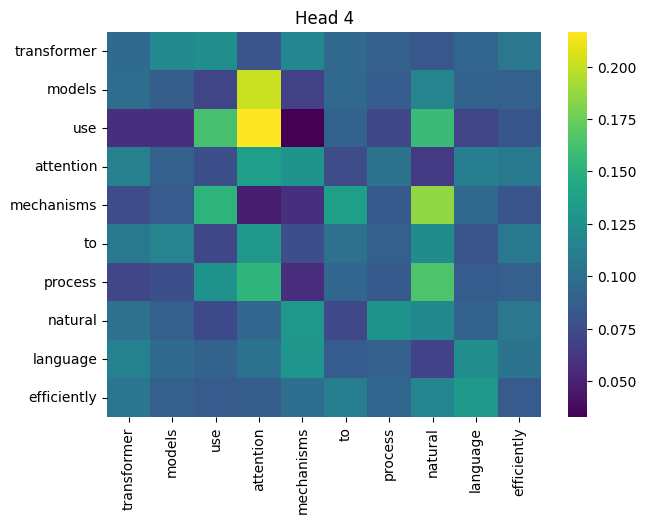

In [12]:
for head in range(4):

    plt.figure(figsize=(7,5))

    sns.heatmap(
        mha_weights[head].detach().numpy(),
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis"
    )

    plt.title(f"Head {head+1}")
    plt.show()

11. Feed Forward Network

In [13]:
class FeedForward(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.fc1 = nn.Linear(d_model, 128)
        self.fc2 = nn.Linear(128, d_model)

    def forward(self, x):

        return self.fc2(F.relu(self.fc1(x)))

12. Transformer Encoder блогын жүзеге асыру

Құрамында:

Multi-Head Attention
Residual Connection
Layer Normalization
Feed Forward Network

In [14]:
class TransformerEncoderBlock(nn.Module):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.mha = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = FeedForward(d_model)

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):

        attn_output, attn_weights = self.mha(x)

        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)

        x = self.norm2(x + ffn_output)

        return x, attn_weights

13. Encoder блогын іске қосу

In [15]:
encoder = TransformerEncoderBlock(
    d_model=32,
    num_heads=4
)

encoder_output, encoder_weights = encoder(X)

print(encoder_output.shape)

torch.Size([10, 32])


In [16]:
torch.Size([10, 32])

torch.Size([10, 32])

14. Дайын PyTorch TransformerEncoder қолдану

In [17]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=32,
    nhead=4,
    batch_first=True
)

official_encoder = nn.TransformerEncoder(
    encoder_layer,
    num_layers=1
)

input_tensor = X.unsqueeze(0)

output = official_encoder(input_tensor)

print(output.shape)

torch.Size([1, 10, 32])


15. Орындау уақытын салыстыру

In [18]:
import time

start = time.time()

for _ in range(100):
    encoder(X)

custom_time = time.time() - start


start = time.time()

for _ in range(100):
    official_encoder(input_tensor)

official_time = time.time() - start


print("Custom Encoder:", custom_time)
print("Official Encoder:", official_time)

Custom Encoder: 0.046643972396850586
Official Encoder: 0.10864496231079102
